In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create an 8x1x8 neural network
model = Sequential([
    Dense(8, activation='relu', input_dim=8),  # Input layer: 8 neurons
    Dense(1, activation='relu'),  # Hidden layer: 1 neurons, input: 8 features
    Dense(8, activation='sigmoid')                  # Output layer: 8 neurons
])

# Compile the model
model.compile(optimizer='adam',
              loss='mse',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

digraph G {
rankdir=TB;
concentrate=true;
dpi=60;
splines=ortho;
node [shape=record];
4623165136 [label=<<table border="0" cellborder="1" bgcolor="black" cellpadding="10"><tr><td colspan="2" bgcolor="black"><font point-size="16" color="white"><b>dense</b> (Dense)</font></td></tr><tr><td bgcolor="white"><font point-size="14">Input shape: <b>(None, 8)</b></font></td><td bgcolor="white"><font point-size="14">Output shape: <b>(None, 8)</b></font></td></tr></table>>, fontname=Helvetica, border=0, margin=0];
5485446864 [label=<<table border="0" cellborder="1" bgcolor="black" cellpadding="10"><tr><td colspan="2" bgcolor="black"><font point-size="16" color="white"><b>dense_1</b> (Dense)</font></td></tr><tr><td bgcolor="white"><font point-size="14">Input shape: <b>(None, 8)</b></font></td><td bgcolor="white"><font point-size="14">Output shape: <b>(None, 1)</b></font></td></tr></table>>, fontname=Helvetica, border=0, margin=0];
5493241936 [label=<<table border="0" cellborder="1" bgcolor="black" 

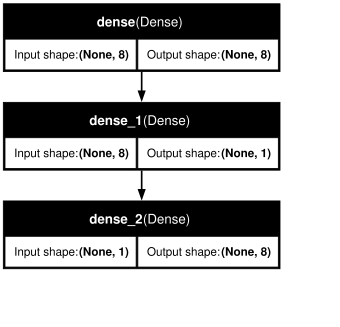

In [2]:
# 展示神经网络的形状结构

from IPython.display import SVG
from tensorflow.keras.utils import model_to_dot
dot = model_to_dot(model, show_shapes=True)
dot.set('dpi', '60')
print(dot)
SVG(dot.create(prog='dot', format='svg'))

In [3]:
import numpy as np

# 创建训练数据 - 每个输入是一个8维的one-hot向量
X_train = np.array([
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])

# 输出数据与输入相同（恒等函数）
y_train = X_train.copy()

# 训练模型
history = model.fit(X_train, y_train, epochs=5000, verbose=0)

# 评估模型性能
loss, accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"最终损失：{loss:.4f}， 准确率：{accuracy:.4f}")

# 测试模型
predictions = model.predict(X_train)
print("\n预测结果：")
for i in range(len(X_train)):
    print(f"输入：{X_train[i]} -> 预测输出：{predictions[i]}，期望： {y_train[i]}")
    print("-" * 50)

最终损失：0.0848， 准确率：0.3750
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

预测结果：
输入：[1 0 0 0 0 0 0 0] -> 预测输出：[0.15174276 0.1652548  0.14516042 0.14658898 0.01403265 0.12403406
 0.15222947 0.1484906 ]，期望： [1 0 0 0 0 0 0 0]
--------------------------------------------------
输入：[0 1 0 0 0 0 0 0] -> 预测输出：[5.6862853e-02 8.6083519e-01 2.4752216e-02 3.0839574e-02 8.6440415e-18
 7.2977220e-04 5.0237581e-02 3.6681253e-02]，期望： [0 1 0 0 0 0 0 0]
--------------------------------------------------
输入：[0 0 1 0 0 0 0 0] -> 预测输出：[0.15622035 0.15078986 0.1527747  0.15338156 0.04129384 0.14328152
 0.15728198 0.15467466]，期望： [0 0 1 0 0 0 0 0]
--------------------------------------------------
输入：[0 0 0 1 0 0 0 0] -> 预测输出：[0.15554772 0.15287307 0.15162201 0.15235534 0.03524513 0.1402694
 0.15652208 0.15374188]，期望： [0 0 0 1 0 0 0 0]
--------------------------------------------------
输入：[0 0 0 0 1 0 0 0] -> 预测输出：[0.1783356  0.0969587  0.19229035 0.18817797 0.8782741  0.26533243
 0.18243274 0.18603288]，期望： [0 0 0 0 1 0